In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv('data4.csv')
df

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,...,stores,id_games,achievements_count,a_count,series_count,dev_team_count,rating_norm,reviews_log,reviews_norm,score
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,...,['Steam'],965470,0.0,0.0,0.0,1.0,0.739130,5.379897,0.604780,0.651803
1,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,...,['Steam'],994601,0.0,0.0,1.0,1.0,0.000000,1.791759,0.201420,0.130923
2,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,...,"['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0,0.948240,6.455199,0.725660,0.803563
3,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0,0.751553,7.799753,0.876807,0.832968
4,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0,0.708075,7.663408,0.861480,0.807788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7418,https://store.steampowered.com/app/1446350/You...,You Will Die Here Tonight,2023-10-31,Spiral Bound Interactive LLC,"['Action', 'Adventure', 'Indie', 'RPG']","19,50€",0%,1.0,"['Dark', 'Psychological Horror', 'Zombies', 'C...",0.00,...,"['Steam', 'GOG']",968736,15.0,0.0,0.0,0.0,0.000000,0.693147,0.077920,0.050648
7419,https://store.steampowered.com/app/1298140/Fob...,Fobia - St. Dinfna Hotel,2022-06-28,Pulsatrix Studios,['Indie'],"24,99€",0%,0.0,"['Indie', 'Survival Horror', 'Puzzle', 'Violen...",3.27,...,"['Steam', 'itch.io']",484814,23.0,0.0,0.0,0.0,0.677019,2.772589,0.311680,0.439548
7420,https://store.steampowered.com/app/1161490/Mot...,MotoGP™20,2020-04-23,Milestone S.r.l.,"['Racing', 'Simulation', 'Sports']","19,99€",0%,1.0,"['Racing', 'Sports', 'Simulation', 'Motorbike'...",3.38,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",413881,54.0,0.0,14.0,0.0,0.699793,3.091042,0.347479,0.470789
7421,https://store.steampowered.com/app/1611430/The...,The Bridge Curse Road to Salvation,2022-08-24,SOFTSTAR ENTERTAINMENT,"['Action', 'Adventure', 'RPG']","16,79€",0%,1.0,"['Horror', 'First-Person', 'Puzzle', 'Explorat...",0.00,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",840800,22.0,0.0,1.0,0.0,0.000000,1.098612,0.123500,0.080275


мы хотим посчитать “успех игры”, но напрямую его нет в данных поэтому собираем его из двух вещей: сколько людей играли и понравилась ли им игра, поэтому берем отзывы как основу, потому что они показывают, сколько людей реально играли, а это главный признак успеха, а рейтинг добавляем с меньшим весом, чтобы учитывать качество, но не считать успешной игру, в которую почти никто не играл

Сначала приведенм данные с которыми будем работать к общему виду, будем оцнивать влияние цены и коммерческих факторов.

In [53]:
df['discount'].info()
df['price'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7423 entries, 0 to 7422
Series name: discount
Non-Null Count  Dtype 
--------------  ----- 
7423 non-null   object
dtypes: object(1)
memory usage: 58.1+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 7423 entries, 0 to 7422
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
7423 non-null   object
dtypes: object(1)
memory usage: 58.1+ KB


Приведем оба значения к числовому виду

In [54]:
df['price'] = df['price'].replace('Free To Play', '0')
df['price'] = df['price'].str.replace(',', '.')
df['price'] = df['price'].str.replace('€', '')
df['price'].unique() #можем увидеть, что помимо цены и бесплатных предложений, встречается еще «мусор» связнанный с демоверсией игры и т.п,

array(['0', '22.99', '100.24', '59.99', '44.99', '39.99', '69.99',
       '19.99', '196.25', '153.90', '19.50', '19.96', '142.10', '7.49',
       '2.49', '9.99', '560.25', '7.79', '49.99', '43.14', '28.45',
       '69.94', '7.99', '9.49', '28.99', '40.93', '38.89', '18.99',
       '22.50', '166.80', '37.49', '19.90', '4.99', '79.99',
       'Factorio Demo', '24.46', '29.99', '38.99', '499.47', '99.99',
       '156.93', '59.98', '14.99', '13.99', '31.99', '9.75', '33.99',
       '17.99', '23.99', '58.99', '31.15', '57.99', '87.39', '17.67',
       '27.75', '36.99', '27.99', '13.79', '63.89', '20.49', '24.50',
       '61.18', '5.99', 'Free to Play', '12.99', '24.99', '156.68',
       '4.49', '9.58', '15.96', '43.99', '26.02', '54.99', '32.99',
       '12.10', '2.91', '18.48', '18.49', '91.86', '10.25', '21.59',
       '20.99', '8.98', '12.49', '16.99', '34.99', '106.89', '38.84',
       '16.79', '12.79', '9.09', '14.79', '23.49', '5.45', '11.79',
       '7.99 / month', '11.43', '14.71', 

In [55]:
df['price'] = pd.to_numeric(df['price'],errors='coerce') #заменим весь подобный мусор на пропуски
df['price'].isna().sum()

np.int64(137)

Количество пропусков не такое большое, поэтому без значимых потерь просто удалим эти строки

In [56]:
df= df.dropna(subset=["price"])

In [57]:
df['price'].isna().sum()

np.int64(0)

In [58]:
df['discount'] = df['discount'].str.replace('%', '')
df['discount'] = df['discount'].str.replace('-', '')
df['discount'] = df['discount'].astype(float)

/tmp/ipykernel_37613/246500986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['discount'] = df['discount'].str.replace('%', '')
/tmp/ipykernel_37613/246500986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['discount'] = df['discount'].str.replace('-', '')
/tmp/ipykernel_37613/246500986.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

In [59]:
df['discount'].info()
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 7286 entries, 0 to 7422
Series name: discount
Non-Null Count  Dtype  
--------------  -----  
7286 non-null   float64
dtypes: float64(1)
memory usage: 113.8 KB
<class 'pandas.core.series.Series'>
Index: 7286 entries, 0 to 7422
Series name: price
Non-Null Count  Dtype  
--------------  -----  
7286 non-null   float64
dtypes: float64(1)
memory usage: 113.8 KB


Отлично, теперь можем рабоать с этими столбцами

Итак, предположу, что цена непостредственно влияет на «успех» игры. Ведь кажется, что дорогая игра более качественная и проработанная, а потому и успешная. А так ли это?

In [60]:
df['price'].describe()

,price
count,7286.000000
mean,18.090397
std,18.220182
min,0.000000
25%,7.790000
50%,14.790000
75%,22.990000
max,560.250000


Text(0, 0.5, 'Количество игр')

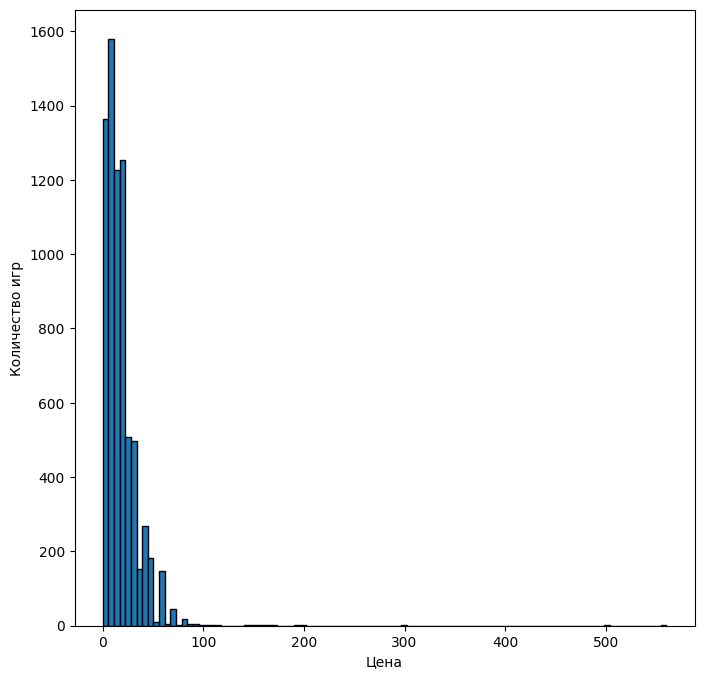

In [61]:
plt.figure(figsize=(8, 8))

plt.hist(df['price'], bins=100, edgecolor='k')

plt.xlabel('Цена')
plt.ylabel('Количество игр')

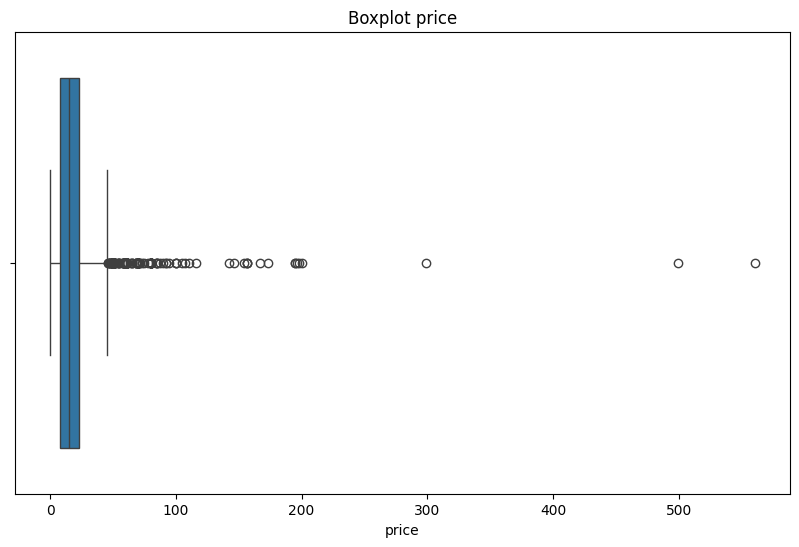

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Boxplot price')
plt.show()

Изучив данные по цене в датасете, посредством визуализаций и метода describe(), можем прийти к следующим выводам:
1. данные сконцентрированны в диапазоне примерно от 0 до 25 евро, большое количество 0, так как есть множество бесплатных игр и присутвуют сильные выбросы, тк (max	560.25), а 75% процентов значений распологаются до	22.99
2. распределение явялется правосторонне ассиметричным, потому что среднее значение примерно 18, что превышает медиану которая примерно равна 15, что также говорит о наличии дорогих игр, которые смещают распределение вправо
3. полученные данные говорят также и о самом рынке: большое количесво игр относится к низкому ценовому сегменту

Логарифмируем потому что обычная цена часто распределена очень неровно: игр с маленькой и средней ценой много, а очень дорогих мало, но они сильно тянут ось вправо и из-за этого на обычном графике почти все точки слипаются слева, а дорогие игры растягивают масштаб

/tmp/ipykernel_37613/541688029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_log'] = np.log1p(df['price'])


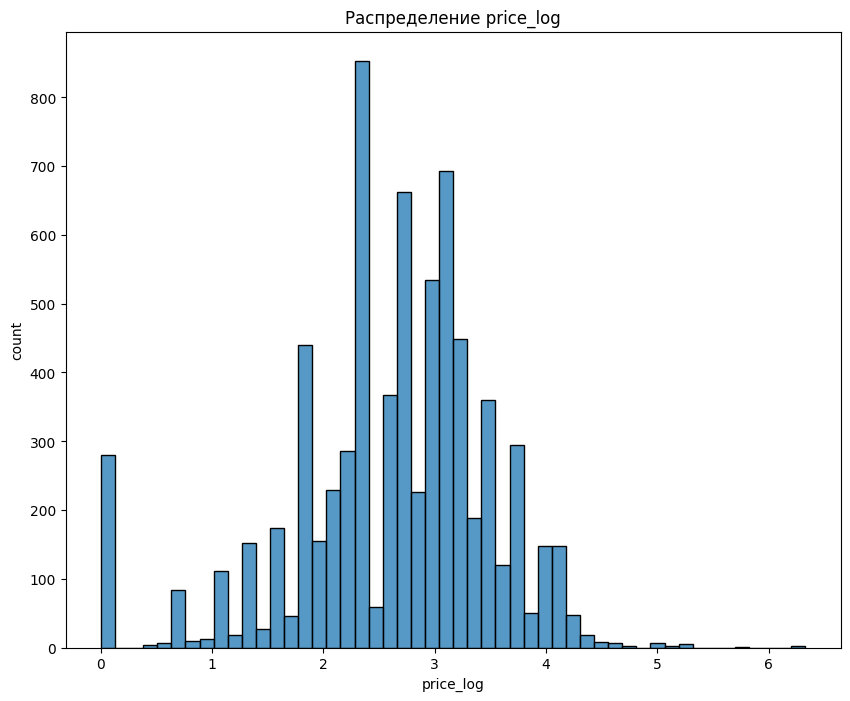

In [63]:
df['price_log'] = np.log1p(df['price'])

plt.figure(figsize=(10, 8))
sns.histplot(df['price_log'], bins=50)
plt.title('Распределение price_log')
plt.xlabel('price_log')
plt.ylabel('count')
plt.show()

После логарифмирования цены распределение стало более равномерным, однако даже в этом случае зависимость между ценой и оценкой не показалась

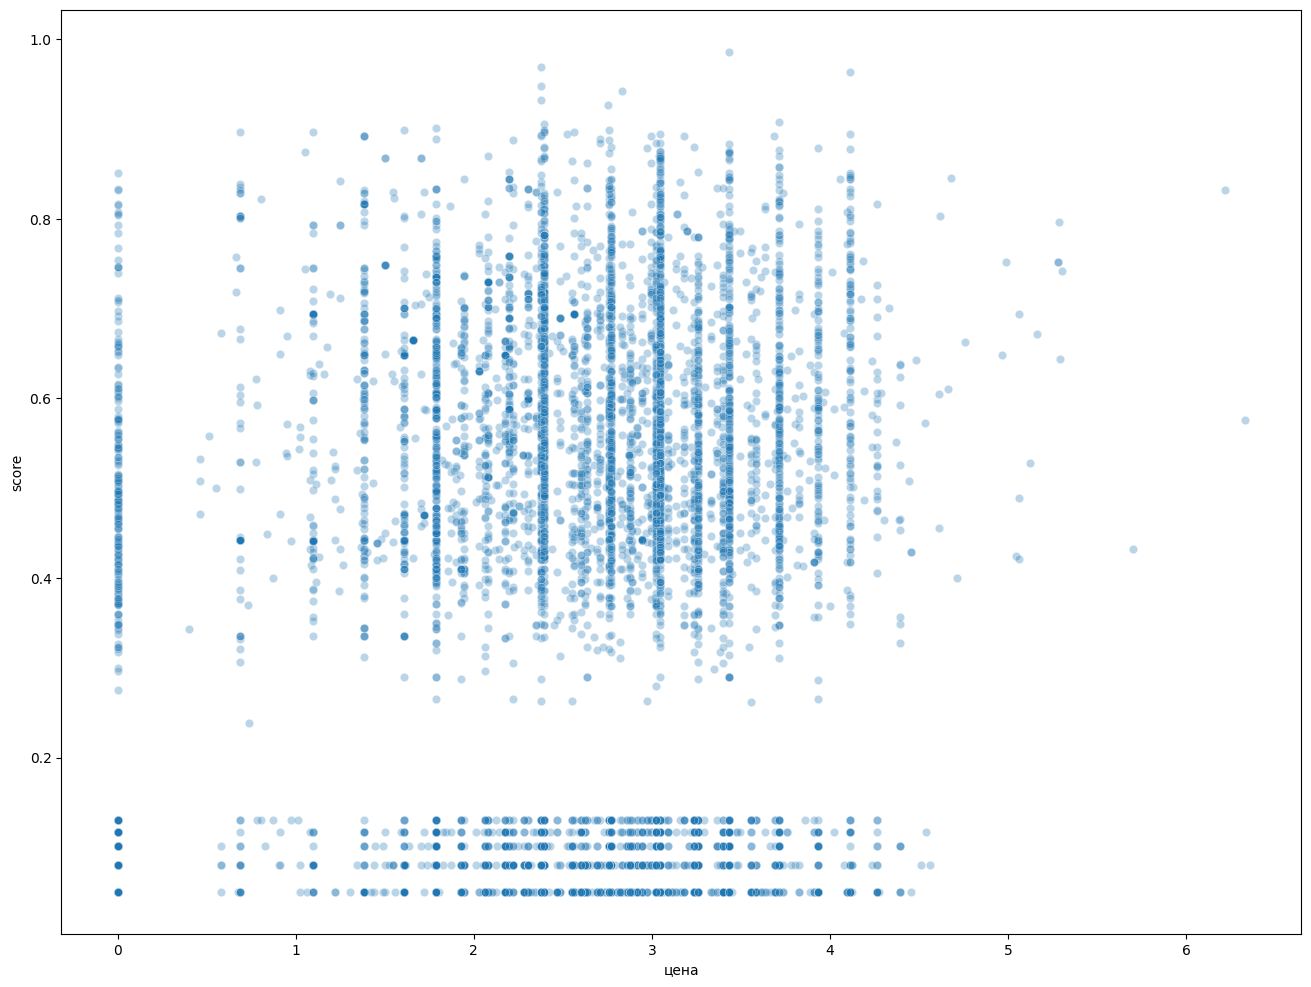

In [64]:
plt.figure(figsize=(16, 12))
sns.scatterplot(data=df, x='price_log', y='score', alpha=0.3)
plt.xlabel('цена')
plt.ylabel('score')
plt.show()

По диаграмме рассеяния видим, что точки распределены довольно хаотично и не образуют выраженного тренда, что говорит о слабой связи

<Axes: >

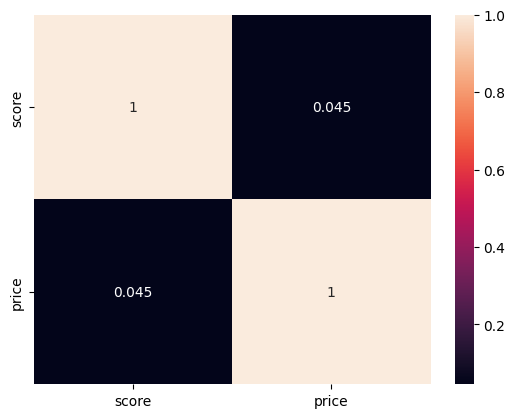

In [65]:
sns.heatmap(df[['score', 'price']].corr(), annot= True)

Видим, что корреляция между ценой и оценкой составляет 0.045, что говорит нам о том, что линейной зависимости между этими переменными отсутсвует

Таким образом придем к выводу, что цена и успех игры не имеет сильной зависимости, скорее более сильное воздействие на «успешность» оказывают другие параметры

Теперь предположим, что чем выше скидка, тем более успешна игра

In [69]:
df['discount'].describe()

,discount
count,7286.000000
mean,7.116113
std,19.843069
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,95.000000


Большее кол-во игр не имеют скидки, это показывает значение медианы и квартилей, которое равно 0. Однако среднее значение положительное хотьь и небольшое, это може объяснить небольшим количеством игр с высокими скидками, которые смещают среднее значение вверх

/tmp/ipykernel_37613/925029111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['has_discount'] = df['discount']>0


<Axes: xlabel='has_discount', ylabel='score'>

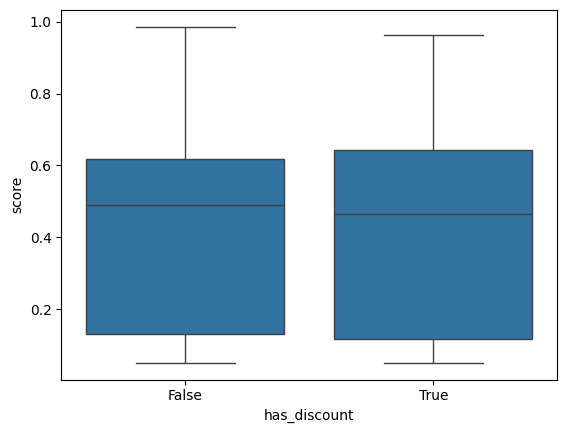

In [71]:
df['has_discount'] = df['discount']>0
sns.boxplot(x='has_discount', y='score', data=df)

Взглянув на визуализацию, где сравниваются игры со скидками и без, можем заметить, что медианы и разброс значений практически не отличаются. Из этого следует, что наличие скидки не связано с более высоким уровнем оценок. Таким образом,мы не можем подтвердить гипотезу о том, что более высокая скидка приводит к большей успешности игры